# Notebook 1: Data Collection & Exploratory Data Analysis
## Nifty 50 Equity Volatility Regime Detection & Forecasting

**Project:** Analysis and Forecasting of Time Series (AFTS)  
**Team:** [Your Names]  
**Institution:** NMIMS  

---

### Objectives
1. Download and clean Nifty 50 daily price data (2010–2024)
2. Also fetch India VIX (benchmark implied volatility)
3. Compute log-returns and basic return statistics
4. Perform comprehensive EDA: distributions, rolling stats, ACF/PACF
5. Conduct stationarity tests (ADF, KPSS) to determine differencing order `d`
6. Visually establish the case for volatility clustering → motivation for ARCH/GARCH

---

In [3]:
# !pip install yfinance

In [4]:
# ── Core imports ──────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

# Time series specific
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

import yfinance as yf
import os

# Plotting style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})
PALETTE = ['#2563eb', '#dc2626', '#16a34a', '#d97706', '#7c3aed']
print('Imports successful ✓')

Imports successful ✓


## 1. Data Collection

We fetch Nifty 50 (`^NSEI`) and India VIX (`^INDIAVIX`) from Yahoo Finance.

> **Note:** If Yahoo Finance is unavailable, the cell below also provides a fallback that generates synthetic data with realistic statistical properties for offline development.

In [5]:
START_DATE = '2010-01-01'
END_DATE   = '2024-12-31'
DATA_DIR   = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

def download_or_load(ticker, filename, start=START_DATE, end=END_DATE):
    """Download from Yahoo Finance; fallback to CSV if already saved."""
    filepath = os.path.join(DATA_DIR, filename)
    if os.path.exists(filepath):
        print(f'  Loading cached {filename} ...')
        return pd.read_csv(filepath, index_col=0, parse_dates=True)
    try:
        print(f'  Downloading {ticker} from Yahoo Finance ...')
        df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
        df.to_csv(filepath)
        print(f'  Saved to {filepath}')
        return df
    except Exception as e:
        print(f'  Download failed ({e}). Generating synthetic data for development ...')
        return None

def generate_synthetic_nifty(start=START_DATE, end=END_DATE):
    """
    Synthetic Nifty 50 with:
    - Realistic annual drift (~12%) and volatility (~18%)
    - GARCH-like volatility clustering
    - Crash periods mimicking COVID (2020-03) and 2018 sell-off
    """
    np.random.seed(42)
    dates = pd.bdate_range(start=start, end=end)
    n = len(dates)
    
    # GARCH(1,1) process for volatility
    omega, alpha, beta = 0.00001, 0.08, 0.90
    sigma2 = np.zeros(n)
    eps    = np.zeros(n)
    sigma2[0] = omega / (1 - alpha - beta)
    
    for t in range(1, n):
        sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]
        eps[t] = np.sqrt(sigma2[t]) * np.random.standard_t(df=5)
    
    # Inject crash shocks
    crash_idx = np.where((dates >= '2020-02-20') & (dates <= '2020-03-23'))[0]
    eps[crash_idx] -= 0.025  # sustained negative drift during crash
    
    drift  = 0.12 / 252  # daily drift
    log_r  = drift + eps
    prices = 5000 * np.exp(np.cumsum(log_r))
    
    df = pd.DataFrame({'Close': prices}, index=dates)
    print(f'  Synthetic data: {len(df)} trading days from {df.index[0].date()} to {df.index[-1].date()}')
    return df

# ── Fetch data ────────────────────────────────────────────────────────────────
print('Fetching Nifty 50 ...')
nifty_raw = download_or_load('^NSEI', 'nifty50_raw.csv')
if nifty_raw is None:
    nifty_raw = generate_synthetic_nifty()

print('\nFetching India VIX ...')
vix_raw = download_or_load('^INDIAVIX', 'india_vix_raw.csv')

print('\nDone.')

Fetching Nifty 50 ...
  Saved to data\nifty50_raw.csv

Fetching India VIX ...
  Saved to data\india_vix_raw.csv

Done.


In [6]:
# ── Clean and build master DataFrame ─────────────────────────────────────────
def clean_price_series(df, col='Close'):
    """Extract Close, drop NaNs, ensure monotone business-day index."""
    if isinstance(df.columns, pd.MultiIndex):
        df = df.xs('Close', axis=1, level=0) if 'Close' in df.columns.get_level_values(0) else df
        df = df.squeeze()
        df = df.to_frame(name='Close') if isinstance(df, pd.Series) else df
    if col in df.columns:
        series = df[col].copy()
    else:
        series = df.iloc[:, 0].copy()
    series = series.dropna()
    series = series[series > 0]
    series.index = pd.to_datetime(series.index)
    series = series.sort_index()
    return series

price  = clean_price_series(nifty_raw)
log_r  = np.log(price / price.shift(1)).dropna()
abs_r  = log_r.abs()
sq_r   = log_r ** 2

# Build master DataFrame
master = pd.DataFrame({
    'price'   : price,
    'log_ret' : log_r,
    'abs_ret' : abs_r,
    'sq_ret'  : sq_r
}).dropna()

# Attach VIX if available
if vix_raw is not None:
    vix = clean_price_series(vix_raw)
    master['vix'] = vix.reindex(master.index)

master.to_csv(os.path.join(DATA_DIR, 'nifty50_master.csv'))

print('Master DataFrame shape:', master.shape)
print(f'Date range: {master.index[0].date()} → {master.index[-1].date()}')
print(f'Trading days: {len(master):,}')
print()
print(master.describe().round(6))

Master DataFrame shape: (3678, 5)
Date range: 2010-01-05 → 2024-12-30
Trading days: 3,678

              price      log_ret      abs_ret       sq_ret          vix
count   3678.000000  3678.000000  3678.000000  3678.000000  3664.000000
mean   10974.809587     0.000410     0.007459     0.000113    18.085925
std     5441.477794     0.010612     0.007558     0.000442     6.121800
min     4544.200195    -0.139038     0.000000     0.000000    10.140000
25%     6101.587524    -0.004914     0.002457     0.000006    14.147500
50%     9382.225098     0.000663     0.005583     0.000031    16.730000
75%    14909.350098     0.006178     0.010061     0.000101    20.572500
max    26216.050781     0.084003     0.139038     0.019331    83.610001


## 2. Price Series Visualisation

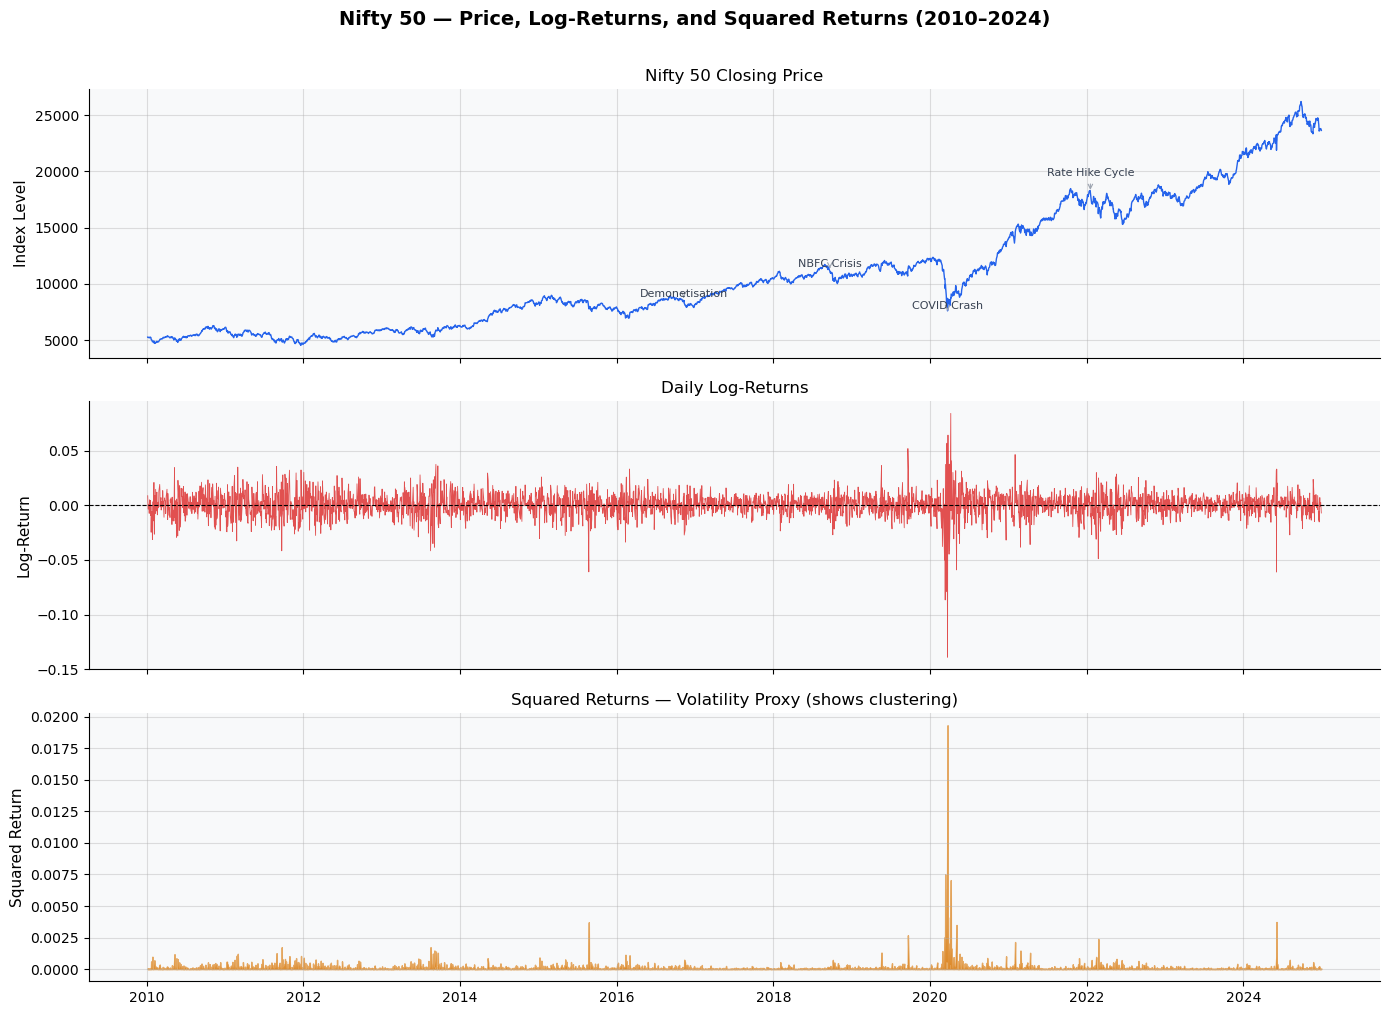

Notice the clustering in squared returns — calm periods followed by turbulent periods.
This is the empirical motivation for GARCH models.


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Nifty 50 — Price, Log-Returns, and Squared Returns (2010–2024)', 
             fontsize=14, fontweight='bold', y=1.01)

# Price
axes[0].plot(master.index, master['price'], color=PALETTE[0], linewidth=1)
axes[0].set_ylabel('Index Level', fontsize=11)
axes[0].set_title('Nifty 50 Closing Price')

# Annotate key events
events = {
    '2016-11-08': ('Demonetisation', -0.03),
    '2018-09-21': ('NBFC Crisis', -0.03),
    '2020-03-23': ('COVID Crash', -0.04),
    '2022-01-18': ('Rate Hike Cycle', 0.02),
}
for date_str, (label, offset) in events.items():
    try:
        d = pd.Timestamp(date_str)
        nearest = master.index[master.index.searchsorted(d)]
        y_val = master.loc[nearest, 'price']
        axes[0].annotate(label, xy=(nearest, y_val), 
                         xytext=(nearest, y_val * (1 + offset + 0.06)),
                         fontsize=8, color='#374151',
                         arrowprops=dict(arrowstyle='->', color='#9ca3af', lw=0.8),
                         ha='center')
    except Exception:
        pass

# Log-returns
axes[1].plot(master.index, master['log_ret'], color=PALETTE[1], linewidth=0.6, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('Log-Return', fontsize=11)
axes[1].set_title('Daily Log-Returns')

# Squared returns (volatility proxy)
axes[2].fill_between(master.index, master['sq_ret'], color=PALETTE[3], alpha=0.6)
axes[2].set_ylabel('Squared Return', fontsize=11)
axes[2].set_title('Squared Returns — Volatility Proxy (shows clustering)')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('plots/01_price_returns_overview.png', dpi=150, bbox_inches='tight')
os.makedirs('plots', exist_ok=True)
plt.tight_layout()
plt.savefig('plots/01_price_returns_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Notice the clustering in squared returns — calm periods followed by turbulent periods.')
print('This is the empirical motivation for GARCH models.')

## 3. Return Distribution Analysis

Financial returns are empirically known to be:
- **Non-normal** (fat tails / leptokurtic)
- **Negatively skewed** (crashes are larger than rallies)

We test this formally.

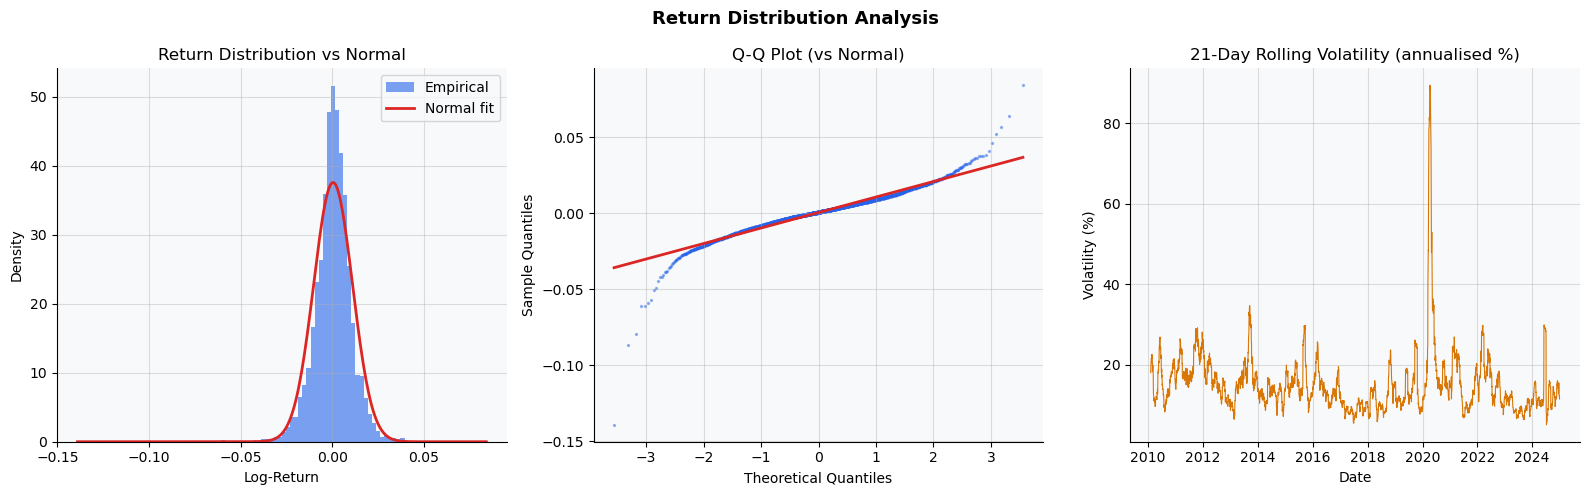

RETURN STATISTICS
  Mean (daily)        : 0.000410
  Mean (annualised)   : 0.1033
  Std Dev (daily)     : 0.010612
  Std Dev (annualised): 0.1685
  Skewness            : -0.9309  (negative = left tail heavier)
  Excess Kurtosis     : 13.5784  (>0 = fat tails)

Jarque-Bera Test
  Statistic : 28702.45
  p-value   : 0.00e+00
  Conclusion: Returns are NOT normally distributed (α=0.05)


In [9]:
os.makedirs('plots', exist_ok=True)
r = master['log_ret'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Return Distribution Analysis', fontsize=13, fontweight='bold')

# Histogram + KDE vs Normal
ax = axes[0]
x_range = np.linspace(r.min(), r.max(), 300)
normal_pdf = stats.norm.pdf(x_range, r.mean(), r.std())
ax.hist(r, bins=100, density=True, color=PALETTE[0], alpha=0.6, label='Empirical')
ax.plot(x_range, normal_pdf, color=PALETTE[1], linewidth=2, label='Normal fit')
ax.set_title('Return Distribution vs Normal')
ax.set_xlabel('Log-Return'); ax.set_ylabel('Density')
ax.legend()

# QQ-Plot
ax = axes[1]
qq = stats.probplot(r, dist='norm')
ax.scatter(qq[0][0], qq[0][1], s=2, color=PALETTE[0], alpha=0.4)
ax.plot(qq[0][0], qq[1][0]*qq[0][0] + qq[1][1], color=PALETTE[1], linewidth=2)
ax.set_title('Q-Q Plot (vs Normal)')
ax.set_xlabel('Theoretical Quantiles'); ax.set_ylabel('Sample Quantiles')

# Rolling 21-day volatility (annualised)
ax = axes[2]
roll_vol = r.rolling(21).std() * np.sqrt(252) * 100
ax.plot(master.index, roll_vol, color=PALETTE[3], linewidth=0.8)
ax.set_title('21-Day Rolling Volatility (annualised %)')
ax.set_xlabel('Date'); ax.set_ylabel('Volatility (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('plots/02_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Descriptive statistics ────────────────────────────────────────────────────
print('=' * 50)
print('RETURN STATISTICS')
print('=' * 50)
print(f'  Mean (daily)        : {r.mean():.6f}')
print(f'  Mean (annualised)   : {r.mean()*252:.4f}')
print(f'  Std Dev (daily)     : {r.std():.6f}')
print(f'  Std Dev (annualised): {r.std()*np.sqrt(252):.4f}')
print(f'  Skewness            : {r.skew():.4f}  (negative = left tail heavier)')
print(f'  Excess Kurtosis     : {r.kurtosis():.4f}  (>0 = fat tails)')

# Jarque-Bera normality test
jb_stat, jb_pval = stats.jarque_bera(r)
print(f'\nJarque-Bera Test')
print(f'  Statistic : {jb_stat:.2f}')
print(f'  p-value   : {jb_pval:.2e}')
print(f'  Conclusion: Returns are {"NOT " if jb_pval < 0.05 else ""}normally distributed (α=0.05)')

## 4. Stationarity Tests

ARIMA and GARCH models require **stationarity**. We test:
- **ADF (Augmented Dickey-Fuller):** H₀ = unit root (non-stationary)
- **KPSS:** H₀ = stationary

Price levels are expected to be non-stationary (I(1)); log-returns should be stationary (I(0)).

In [10]:
def adf_test(series, name='Series'):
    """Augmented Dickey-Fuller test with formatted output."""
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'  ADF Test — {name}')
    print(f'    Statistic : {result[0]:.4f}')
    print(f'    p-value   : {result[1]:.6f}')
    print(f'    Lags used : {result[2]}')
    print(f'    Crit 1%   : {result[4]["1%"]:.4f}')
    print(f'    Crit 5%   : {result[4]["5%"]:.4f}')
    stat = 'STATIONARY' if result[1] < 0.05 else 'NON-STATIONARY'
    print(f'    → {stat} at 5% significance\n')
    return result[1] < 0.05

def kpss_test(series, name='Series'):
    """KPSS test (regression='ct' for trend-stationarity)."""
    result = kpss(series.dropna(), regression='ct', nlags='auto')
    print(f'  KPSS Test — {name}')
    print(f'    Statistic : {result[0]:.4f}')
    print(f'    p-value   : {result[1]:.6f}')
    print(f'    Crit 5%   : {result[3]["5%"]:.4f}')
    stat = 'NON-STATIONARY' if result[1] < 0.05 else 'STATIONARY'
    print(f'    → {stat} at 5% significance\n')
    return result[1] >= 0.05

print('=' * 55)
print('STATIONARITY ANALYSIS')
print('=' * 55)

log_price = np.log(master['price'])
print('\n--- LOG PRICE (levels) ---')
adf_test(log_price, 'Log Price')
kpss_test(log_price, 'Log Price')

print('--- LOG-RETURNS (first difference) ---')
adf_test(master['log_ret'], 'Log-Returns')
kpss_test(master['log_ret'], 'Log-Returns')

print('==> CONCLUSION: Log-returns are stationary → d = 0 for ARIMA on returns')
print('    (Apply d=1 differencing to log-price series if modelling prices directly)')

STATIONARITY ANALYSIS

--- LOG PRICE (levels) ---
  ADF Test — Log Price
    Statistic : -0.1829
    p-value   : 0.940534
    Lags used : 12
    Crit 1%   : -3.4321
    Crit 5%   : -2.8623
    → NON-STATIONARY at 5% significance

  KPSS Test — Log Price
    Statistic : 0.6371
    p-value   : 0.010000
    Crit 5%   : 0.1460
    → NON-STATIONARY at 5% significance

--- LOG-RETURNS (first difference) ---
  ADF Test — Log-Returns
    Statistic : -16.9434
    p-value   : 0.000000
    Lags used : 11
    Crit 1%   : -3.4321
    Crit 5%   : -2.8623
    → STATIONARY at 5% significance

  KPSS Test — Log-Returns
    Statistic : 0.0209
    p-value   : 0.100000
    Crit 5%   : 0.1460
    → STATIONARY at 5% significance

==> CONCLUSION: Log-returns are stationary → d = 0 for ARIMA on returns
    (Apply d=1 differencing to log-price series if modelling prices directly)


## 5. ACF and PACF Analysis

ACF/PACF on:
1. **Log-returns** → determine AR(p) and MA(q) orders for ARIMA
2. **Absolute returns** → persistence of volatility
3. **Squared returns** → confirm ARCH effects (significant lags → GARCH warranted)

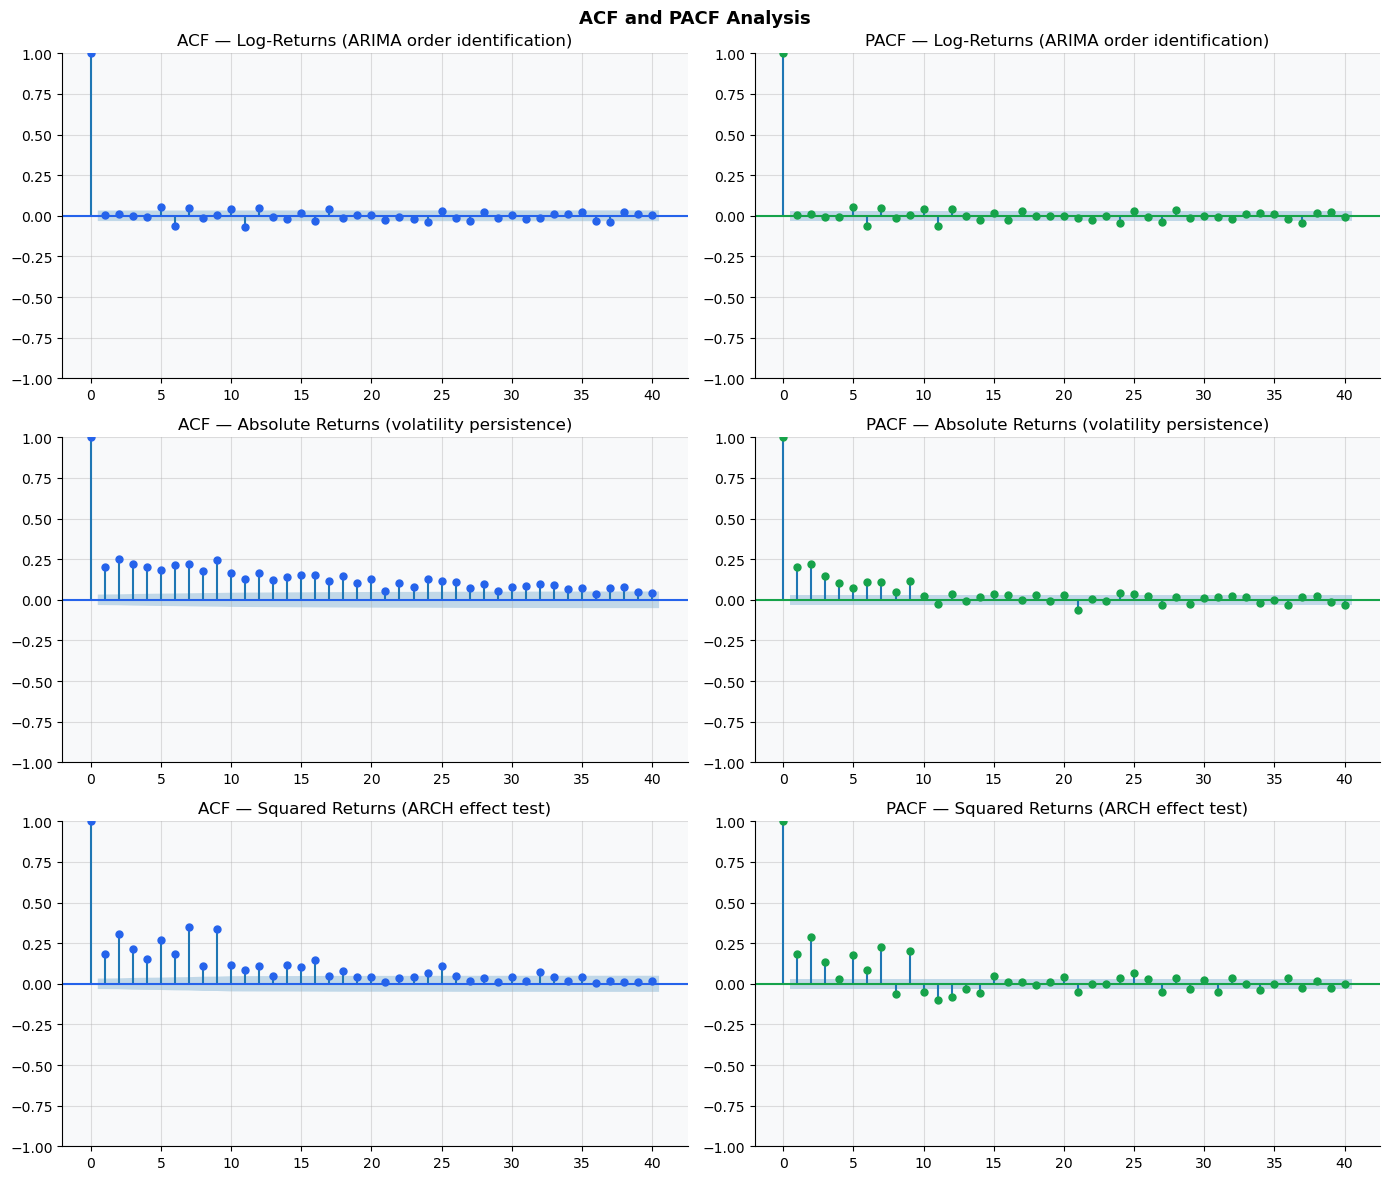

Ljung-Box Test on Squared Returns (H₀: no autocorrelation = no ARCH effect)
        lb_stat      lb_pvalue
5    995.354952  6.088530e-213
10  2084.616055   0.000000e+00
20  2377.586398   0.000000e+00

✓ Significant autocorrelation in squared returns detected.
  → ARCH effects confirmed. GARCH modelling is warranted.


In [11]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('ACF and PACF Analysis', fontsize=13, fontweight='bold')

lags = 40
series_list = [
    (master['log_ret'],  'Log-Returns (ARIMA order identification)'),
    (master['abs_ret'],  'Absolute Returns (volatility persistence)'),
    (master['sq_ret'],   'Squared Returns (ARCH effect test)'),
]

for i, (s, title) in enumerate(series_list):
    plot_acf(s.dropna(), lags=lags, ax=axes[i][0], title=f'ACF — {title}', color=PALETTE[0])
    plot_pacf(s.dropna(), lags=lags, ax=axes[i][1], title=f'PACF — {title}', color=PALETTE[2])

plt.tight_layout()
plt.savefig('plots/03_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

# Ljung-Box test on squared returns (formal ARCH effect test)
lb = acorr_ljungbox(master['sq_ret'].dropna(), lags=[5, 10, 20], return_df=True)
print('Ljung-Box Test on Squared Returns (H₀: no autocorrelation = no ARCH effect)')
print(lb.to_string())
print()
if (lb['lb_pvalue'] < 0.05).any():
    print('✓ Significant autocorrelation in squared returns detected.')
    print('  → ARCH effects confirmed. GARCH modelling is warranted.')
else:
    print('  No significant ARCH effects detected at these lags.')

## 6. Rolling Statistics — Structural Break Detection

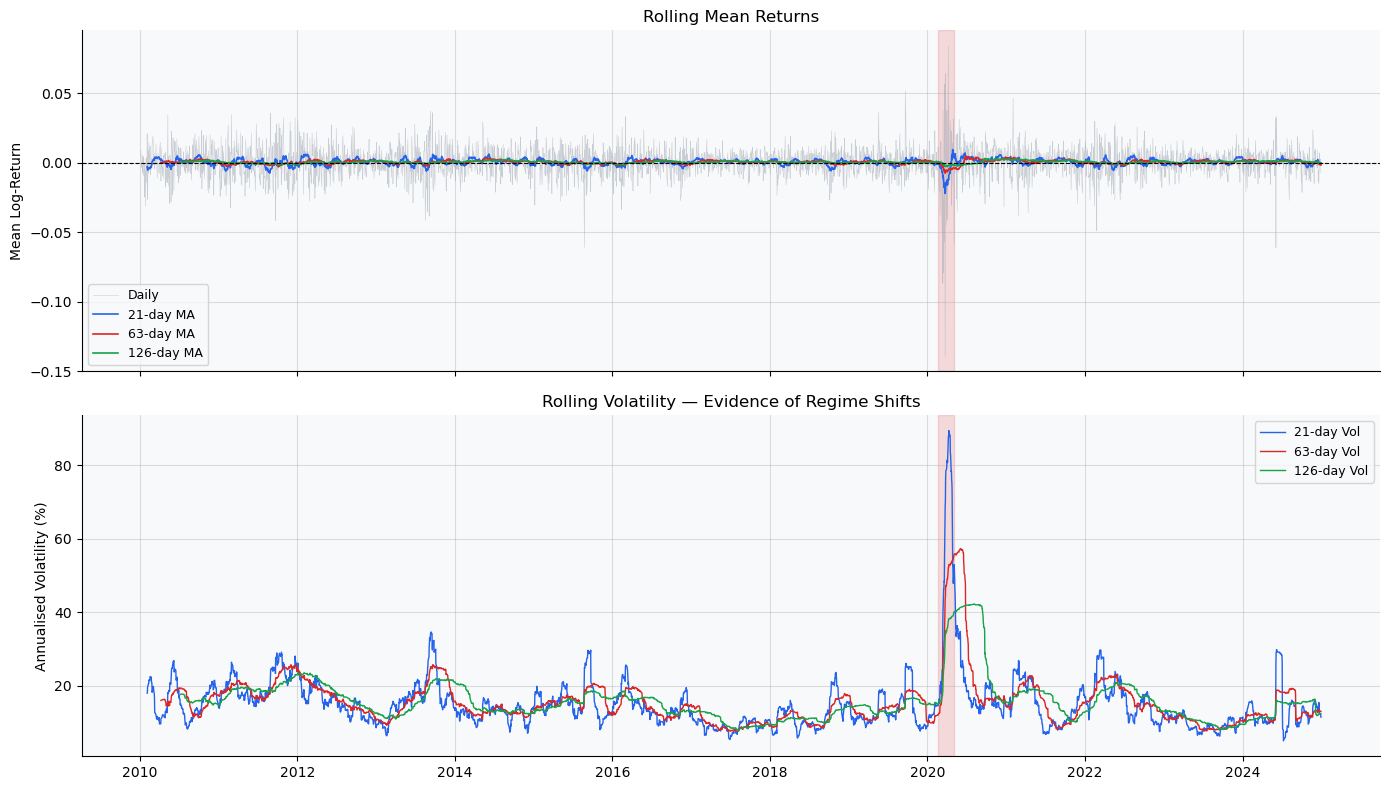

In [12]:
windows = [21, 63, 126]  # 1-month, 1-quarter, 6-month

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Rolling mean
ax = axes[0]
ax.plot(master.index, master['log_ret'], color='#9ca3af', linewidth=0.4, alpha=0.5, label='Daily')
for w, col in zip(windows, PALETTE):
    ax.plot(master.index, master['log_ret'].rolling(w).mean(), 
            color=col, linewidth=1.2, label=f'{w}-day MA')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Mean Log-Return'); ax.set_title('Rolling Mean Returns')
ax.legend(fontsize=9)

# Rolling std (volatility)
ax = axes[1]
for w, col in zip(windows, PALETTE):
    roll_vol = master['log_ret'].rolling(w).std() * np.sqrt(252) * 100
    ax.plot(master.index, roll_vol, color=col, linewidth=1, label=f'{w}-day Vol')
ax.set_ylabel('Annualised Volatility (%)')
ax.set_title('Rolling Volatility — Evidence of Regime Shifts')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)

# Mark regimes
crash_periods = [('2020-02-20', '2020-05-01', 'COVID-19', PALETTE[1])]
for s, e, label, col in crash_periods:
    for axis in axes:
        axis.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.15, color=col)

plt.tight_layout()
plt.savefig('plots/04_rolling_stats.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary & Key Findings

**Document your findings here before moving to Notebook 2.**

In [13]:
print('=' * 60)
print('NOTEBOOK 1 — SUMMARY OF FINDINGS')
print('=' * 60)
print(f"""
Dataset
  Period         : {master.index[0].date()} to {master.index[-1].date()}
  Trading days   : {len(master):,}

Return Characteristics
  Annualised return  : {master['log_ret'].mean() * 252 * 100:.2f}%
  Annualised vol     : {master['log_ret'].std() * np.sqrt(252) * 100:.2f}%
  Skewness           : {master['log_ret'].skew():.3f}  → {'negative (left tail)' if master['log_ret'].skew() < 0 else 'positive (right tail)'}
  Excess kurtosis    : {master['log_ret'].kurtosis():.3f} → fat-tailed distribution

Stationarity
  Log-price          : NON-STATIONARY (I(1)) → first-difference required
  Log-returns        : STATIONARY (I(0)) → use directly in ARIMA/GARCH
  Differencing order : d = 0 (for ARIMA on log-returns)

ARCH Effects
  Ljung-Box on sq. returns: significant → GARCH modelling warranted
  Visual volatility clustering: confirmed

Takeaway for Notebook 2
  → Model log-returns with ARIMA(p, 0, q)
  → Use STL decomposition on price levels for trend/seasonality
  → ARIMA residuals will be passed to GARCH in Notebook 3
""")

NOTEBOOK 1 — SUMMARY OF FINDINGS

Dataset
  Period         : 2010-01-05 to 2024-12-30
  Trading days   : 3,678

Return Characteristics
  Annualised return  : 10.33%
  Annualised vol     : 16.85%
  Skewness           : -0.931  → negative (left tail)
  Excess kurtosis    : 13.578 → fat-tailed distribution

Stationarity
  Log-price          : NON-STATIONARY (I(1)) → first-difference required
  Log-returns        : STATIONARY (I(0)) → use directly in ARIMA/GARCH
  Differencing order : d = 0 (for ARIMA on log-returns)

ARCH Effects
  Ljung-Box on sq. returns: significant → GARCH modelling warranted
  Visual volatility clustering: confirmed

Takeaway for Notebook 2
  → Model log-returns with ARIMA(p, 0, q)
  → Use STL decomposition on price levels for trend/seasonality
  → ARIMA residuals will be passed to GARCH in Notebook 3

